Challenge: Analyzing Text about Data Science
In this notebook, we experiment with using different URL - wikipedia article on Machine Learning. You can see that, unlike Data Science, this article contains a lot of terms, this making the analysis more problematic. We need to come up with another way to clean up the data after doing keyword extraction, to get rid of some frequent, but not meaningful word combinations.

In this example, let's do a simple exercise that covers all steps of a traditional data science process. You do not have to write any code, you can just click on the cells below to execute them and observe the result. As a challenge, you are encouraged to try this code out with different data.

Goal
In this lesson, we have been discussing different concepts related to Data Science. Let's try to discover more related concepts by doing some text mining. We will start with a text about Data Science, extract keywords from it, and then try to visualize the result.

As a text, I will use the page on Data Science from Wikipedia:
experiment with実験する
some [ frequent ] but [ not meaningful ] word combinations
,toなぜなら
try out 試す
mining採掘
start withから始める


In [1]:

url = 'https://en.wikipedia.org/wiki/Data_science'
url = 'https://en.wikipedia.org/wiki/Machine_learning'
#この時点でurl = 'https://en.wikipedia.org/wiki/Data_science'は'https://en.wikipedia.org/wiki/Machine_learning'に書き換えられるので消滅

Step 1: Getting the Data
First step in every data science process is getting the data. We will use requests library to do that:

In [2]:
import requests
#身分証の提示
#headerは送るデータの先頭につけるものだからheaderという名前が付けられる
headers={
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}
#.content
#   requestライブラリのプロパティの一つ、生のデータの受け皿
#.decode
#   pythonメソッドの一つ、人間が読める文字に変換する
text=requests.get(url,headers=headers).content.decode('utf-8')
print(text[:1000])

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available skin-thumbsize-clientpref-standard" lang="en" dir="ltr">
<head>
<meta charset="UTF-8">
<title>Machine learning - Wikipedia</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-menu-disabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vec

The next step is to convert the data into the form suitable for processing. In our case, we have downloaded HTML source code from the page, and we need to convert it into plain text.

There are many ways this can be done. We will use BeautifulSoup, a popular Python library for parsing HTML. BeautifulSoup allows us to target specific HTML elements, so we can focus on the main article content from Wikipedia and reduce some navigation menus, sidebars, footers, and other irrelevant content (though some boilerplate text may still remain).

First, we need to install the BeautifulSoup library for HTML parsing:

In [3]:
import sys
#-mはpipを動かしてというmoduleの頭文字
!{sys.executable} -m pip install beautifulsoup4


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from bs4 import BeautifulSoup
#''は文字列とパソコンに教えるため
soup=BeautifulSoup(text,'html.parser')
#[ Wikipediaの全体のHTML ]
# │
# ├── [メニューの部屋] ──> 「メインページ」「コミュニティ」などの文字
# │
# ├── [ヘッダーの部屋] ──> ログインボタンなど
# │
# ├── ★ [ div class="mw-parser-output" ] 👈 ココ！！
# │     │
# │     └── 「データサイエンスとは、データを分析して…（本物の本文）」
# │
# └── [フッターの部屋] ──> 「プライバシー・ポリシー」などの文字
#class_
#   pythonのclass(設計図)と被らないように_
content=soup.find('div',class_='mw-parser-output')
#余計なパーツをそぎ落とす,beautifilsoupがやってくれるのは本文を取り出すことだけ
#後から取り出すから[]になっている
#★ [ div class="mw-parser-output" ] （本文の大きな部屋）
# │
# ├── [ .infobox ] ───> 画面右側にある「概要の表（国旗や人口など）」
# │
# ├── [ #toc / .toc ] ─> 記事の最初にある「目次（Table of Contents）」
# │
# ├── [ .mw-editsection ] > 各見出しの横にある「[編集]」という小さなリンク
# │
# ├── [ sup.reference ] > 文章の途中にある「[1]」「[2]」といった注釈の数字
# │
# ├──  ( 本物の本文テキスト：「データサイエンスとは〜」) 👈 欲しいのはココだけ！
# │
# ├─#─ [ .reflist ] ────> 記事の一番下にある「参考文献のリスト」
# │
# └── [ .navbox ] ─────> 記事の最下部にある「関連テーマへの巨大なリンク集」
selectors=[
        '.mw-jump-link',
        '.navbox',
        '.reflist',
        'sup.reference',
        '.mw-editsection',
        '.hatnote',
        '.metadata',
        '.infobox',
        '#toc',
        '.toc',
        '.sidebar',
    ]
#for A in B Bの生データをベルトコンベアにおいてひとつひとつ条件に合ったものを箱につめる、
for selector in selectors:
    for el in content.select(selector):
        el.decompose()

if content:
   clean_text=content.get_text(separator="",strip=True)
   print(clean_text[:1000])
else:
    print("本文が見つかりませんでした")   
    soup.get_text(separator='',strip=True)
    print(text[:1000])

    


Subset of artificial intelligenceMachine learning(ML) is a field of study inartificial intelligenceconcerned with the development and study ofstatistical algorithmsthat can learn fromdataandgeneralizeto unseen data, and thus performtaskswithout being explicitlyprogrammed.Advances in the field ofdeep learninghave allowedneural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.Statisticsandmathematical optimisationmethods compose the foundations of machine learning.Data miningis a related field of study, focusing onexploratory data analysis(EDA) throughunsupervised learning.From a theoretical viewpoint,probably approximately correct learningprovides a mathematical and statistical framework for describing machine learning. Most traditional machine learning and deep learning algorithms can be described asempirical risk minimisationunder this framework.HistoryThe termmachine learningwas coined in 1959 byArthur Samuel, anIBMemplo

Step 3: Getting Insights
The most important step is to turn our data into some form from which we can draw insights. In our case, we want to extract keywords from the text, and see which keywords are more meaningful.
We will use Python library called RAKE for keyword extraction. First, let's install this library in case it is not present:

turn our data intoデータを~に変える
from whichそこから
form形


In [5]:
import sys
!{sys.executable} -m pip install nlp_rake


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import nlp_rake
#nlp_rake.Rake
#   extracting keywords and making ranking
#1,maximam words 2
#2,minimam frequent 3
#3,minimam characters 5
#charactersは文字
extractor = nlp_rake.Rake(max_words=2,min_freq=3,min_chars=5)
res = extractor.apply(clean_text)
res

[('data set', 4.0),
 ('data mining', 4.0),
 ('clarification needed', 4.0),
 ('statistical physics', 4.0),
 ('prentice hall', 4.0),
 ('mit press', 4.0),
 ('retrieved25 november2018', 4.0),
 ('retrieved20 august2018', 4.0),
 ('retrieved11 june2020', 4.0),
 ('retrieved17 january2022', 4.0),
 ('thewayback machine', 3.977777777777778),
 ('artificial neuron', 3.96875),
 ('artificial neurons', 3.96875),
 ('feature learning', 3.9626865671641793),
 ('reinforcement learning', 3.9626865671641793),
 ('statistical learning', 3.9626865671641793),
 ('machine learning', 3.940464344941957),
 ('citation needed', 3.857142857142857),
 ('artificial intelligence', 3.84875),
 ('pattern recognition', 3.833333333333333),
 ('supervised learning', 3.819829424307036),
 ('neural networks', 3.8),
 ('speech recognition', 3.8),
 ('international conference', 3.7777777777777777),
 ('outlier detection', 3.75),
 ('modern approach', 3.75),
 ('ieee transactions', 3.75),
 ('unsupervised learning', 3.6769722814498933),
 ('tr

We obtained a list terms together with associated degree of importance. As you can see, the most relevant disciplines, such as machine learning and big data, are present in the list at top positions.

obtain得る
together withと一緒に
discipline専門分野

Step 4: Visualizing the Result
People can interpret the data best in the visual form. Thus it often makes sense to visualize the data in order to draw some insights. We can use matplotlib library in Python to plot simple distribution of the keywords with their relevance:

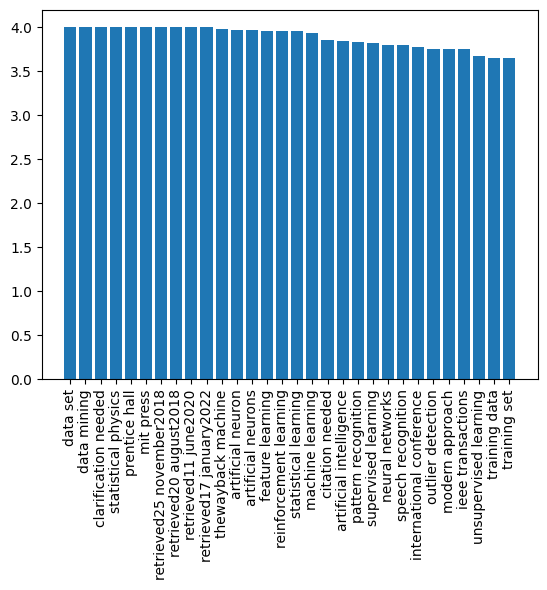

In [ ]:
import matplotlib.pyplot as plt

pair_list=res[:30]
k,v = zip(*pair_list)
#barは実体の設定
#range(len(k)) 棒グラフを並べる数
#v 棒グラフの高さ
plt.bar(range(len(k)),v)
#.xticksはメモリの上書き
#range(len(k))で設定した横軸の0,1,2,にkを上書きして、その文字を90°回転させて
plt.xticks(range(len(k)),k,rotation='vertical')
plt.show()



There is, however, even better way to visualize word frequencies - using Word Cloud. We will need to install another library to plot the word cloud from our keyword list.

In [18]:
import sys
!{sys.executable} -m pip install wordcloud


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


WordCloud object is responsible for taking in either original text, or pre-computed list of words with their frequencies, and returns an image, which can then be displayed using matplotlib

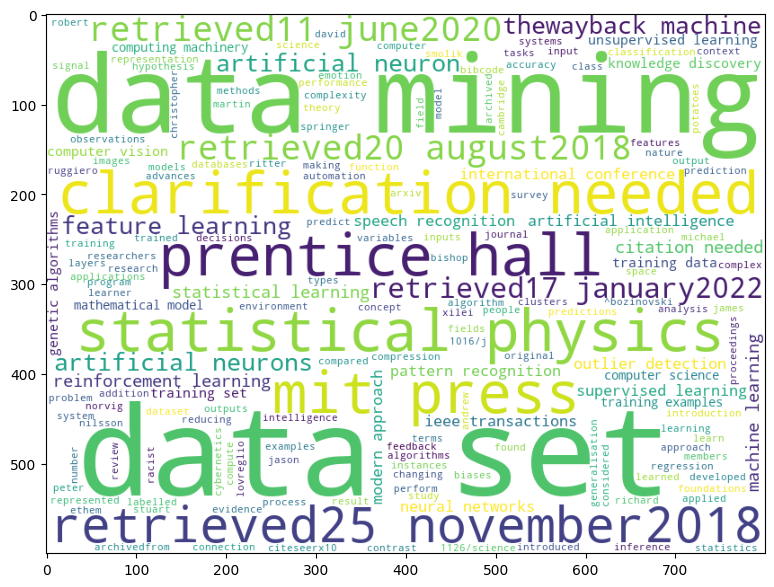

In [19]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
#wcをpltの白紙の紙に張り付ける
#WordCloud()
#1　背景
#2　横幅 
#3　縦幅
wc = WordCloud(background_color='white',width=800,height=600)
#figure()は白紙
#1　横幅
#2　縦幅
plt.figure(figsize=(15,7))
#.imshowは張り付け
#.generate_from_frequenciesは頻度、重要度をもとに画像を生成
plt.imshow(wc.generate_from_frequencies({ k:v for k,v in res }))
plt.show()

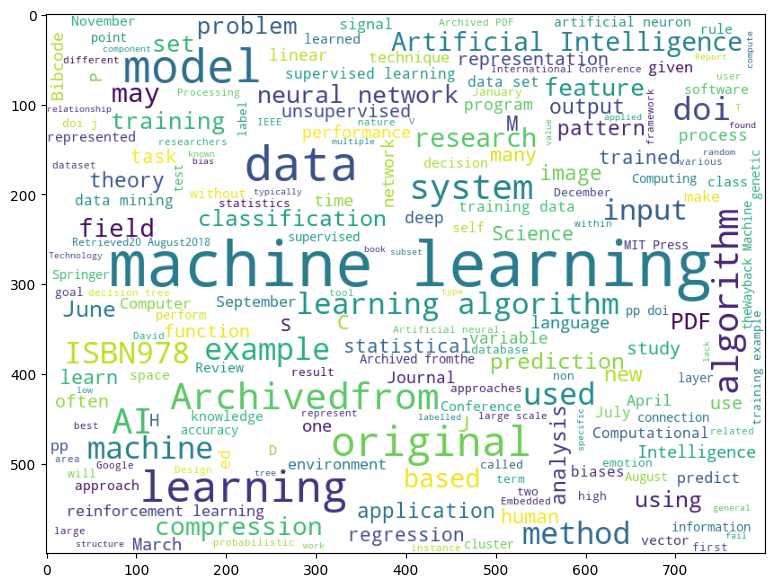

In [22]:
plt.figure(figsize=(15,7))
plt.imshow(wc.generate(clean_text))
plt.show()

In [23]:
wc.generate(clean_text).to_file('images/ds_wordcloud.png')

You can see that word cloud now looks more impressive, but it also contains a lot of noise (eg. unrelated words such as Retrieved on). Also, we get fewer keywords that consist of two words, such as data scientist, or computer science. This is because RAKE algorithm does much better job at selecting good keywords from text. This example illustrates the importance of data pre-processing and cleaning, because clear picture at the end will allow us to make better decisions.

In this exercise we have gone through a simple process of extracting some meaning from Wikipedia text, in the form of keywords and word cloud. This example is quite simple, but it demonstrates well all typical steps a data scientist will take when working with data, starting from data acquisition, up to visualization.

In our course we will discuss all those steps in detail.